# Gen Z Slang Evolution Tracker — Pre-processing + EDA

This notebook is a **simple exploratory data analysis** for the
**GenZ Slang Evolution Tracker (2020–2025)** dataset.

## Goals of this notebook
1. Load the dataset correctly
2. Check data quality (**missing values, duplicates, data types**)
3. Do the main **pre-processing** needed before visualization
4. Compute **basic statistics**
5. Build a few **clear charts** for the milestone



In [26]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cleaner display of tables
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

In [27]:
# Load the dataset

DATA_PATH = "genz_slang_usage_2020_2025.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (535396, 22)


,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,usage_context,lifecycle_phase,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence
0,0,2020-01-01 01:23:17,simp,insult,someone overly devoted to another person,Reddit,Twitter,California,user_019223,25-30,food_related,growing,0.603,negative,-0.740,False,18,2,5,0.004,False,153
1,1,2020-01-01 03:21:59,simp,insult,someone overly devoted to another person,Reddit,Twitter,Texas,user_497341,13-17,food_related,growing,0.603,negative,-0.978,False,24,1,2,0.004,False,153
2,2,2020-01-01 05:31:01,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Canada,user_323563,31-40,casual_conversation,growing,0.552,positive,0.384,False,121,1,0,0.013,False,92
3,3,2020-01-01 05:35:30,no cap,emphasis,"no lie, for real",Twitter,Twitter,Arizona,user_244857,18-24,gaming,growing,0.551,neutral,0.167,False,47,2,1,0.006,False,214
4,4,2020-01-01 06:39:57,no cap,emphasis,"no lie, for real",Twitter,Instagram,Arizona,user_421848,13-17,compliment,growing,0.551,positive,0.874,False,18,0,14,0.006,False,214


##  First look at the dataset

To help us understand what we are working with, before cleaning anything, we inspect:
- the **shape** of the dataset
- the **column names**
- the **data types**
- a preview of the rows

In [28]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic info:")
df.info()

Columns:
['record_id', 'timestamp', 'slang_term', 'term_category', 'term_meaning', 'origin_platform', 'usage_platform', 'region', 'user_id', 'user_age_group', 'usage_context', 'lifecycle_phase', 'intensity_score', 'sentiment', 'sentiment_score', 'ironic_usage', 'likes', 'shares', 'comments', 'virality_score', 'is_viral', 'days_since_emergence']

Data types:
record_id                 int64
timestamp                   str
slang_term                  str
term_category               str
term_meaning                str
origin_platform             str
usage_platform              str
region                      str
user_id                     str
user_age_group              str
usage_context               str
lifecycle_phase             str
intensity_score         float64
sentiment                   str
sentiment_score         float64
ironic_usage               bool
likes                     int64
shares                    int64
comments                  int64
virality_score          float64


## Data quality checks

We check:
- missing values
- duplicate rows
- data types
- whether important numeric columns stay in expected ranges

In [29]:
# Missing values
missing_values = df.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_values)

# Duplicates
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

Missing values per column:
record_id               0
timestamp               0
is_viral                0
virality_score          0
comments                0
shares                  0
likes                   0
ironic_usage            0
sentiment_score         0
sentiment               0
intensity_score         0
lifecycle_phase         0
usage_context           0
user_age_group          0
user_id                 0
region                  0
usage_platform          0
origin_platform         0
term_meaning            0
term_category           0
slang_term              0
days_since_emergence    0
dtype: int64

Number of duplicate rows: 0


In [30]:
# Validation of expected numeric ranges

range_checks = {
    "intensity_score": (0, 1),
    "sentiment_score": (-1, 1),
    "virality_score": (0, 1),
    "days_since_emergence": (0, None),
    "likes": (0, None),
    "shares": (0, None),
    "comments": (0, None),
}

print("Range checks:")
for col, (min_val, max_val) in range_checks.items():
    if col in df.columns:
        series = df[col]
        ok_min = True if min_val is None else (series >= min_val).all()
        ok_max = True if max_val is None else (series <= max_val).all()
        print(f"- {col}: min={series.min()}, max={series.max()}, valid_range={ok_min and ok_max}")

Range checks:
- intensity_score: min=0.09, max=1.0, valid_range=True
- sentiment_score: min=-1.0, max=1.0, valid_range=True
- virality_score: min=0.0, max=1.0, valid_range=True
- days_since_emergence: min=0, max=1428, valid_range=True
- likes: min=0, max=35200, valid_range=True
- shares: min=0, max=3990, valid_range=True
- comments: min=0, max=6121, valid_range=True


##  Actual pre-processing

The dataset is already quite clean, so the pre-processing is light but makes the dataset easier to analyze and visualize.

We will:
1. clean column names
2. convert `timestamp` to datetime
3. create useful time columns (`year`, `month`, `year_month`)
4. convert repeated text columns into categorical variables


In [31]:
# Clean column names 
df.columns = df.columns.str.strip().str.lower()

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Create useful time columns
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["year_month"] = df["timestamp"].dt.to_period("M").astype(str)

# Convert repeated text columns to category
categorical_cols = [
    "slang_term",
    "term_category",
    "origin_platform",
    "usage_platform",
    "region",
    "user_age_group",
    "usage_context",
    "lifecycle_phase",
    "sentiment",
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Updated data types:")
print(df.dtypes)

Updated data types:
record_id                        int64
timestamp               datetime64[us]
slang_term                    category
term_category                 category
term_meaning                       str
origin_platform               category
usage_platform                category
region                        category
user_id                            str
user_age_group                category
usage_context                 category
lifecycle_phase               category
intensity_score                float64
sentiment                     category
sentiment_score                float64
ironic_usage                      bool
likes                            int64
shares                           int64
comments                         int64
virality_score                 float64
is_viral                          bool
days_since_emergence             int64
year                             int32
month                            int32
year_month                         str
dtype

In [32]:
# Check whether timestamp conversion worked
print("Null timestamps after conversion:", df["timestamp"].isna().sum())
print("Minimum timestamp:", df["timestamp"].min())
print("Maximum timestamp:", df["timestamp"].max())

Null timestamps after conversion: 0
Minimum timestamp: 2020-01-01 01:23:17
Maximum timestamp: 2025-12-31 23:52:04


## Global descriptive statistics

`describe(include='all')`

It is useful because:
- for **categorical columns**, it shows the number of unique values, the most frequent value, and its frequency
- for **numeric columns**, it shows count, mean, std, min, quartiles, and max


In [33]:
desc = df.describe(include="all").T
desc

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
record_id,535396.0,NaN,NaN,NaN,267697.5,0.0,133848.75,267697.5,401546.25,535395.0,154555.656699
timestamp,535396,NaN,NaN,NaN,2023-02-15 18:27:32.009215,2020-01-01 01:23:17,2021-11-24 15:32:47,2023-03-22 15:05:47,2024-05-17 16:25:32.500000,2025-12-31 23:52:04,NaN
slang_term,535396,46,slay,19004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
term_category,535396,17,approval,106901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
term_meaning,535396,46,doing something exceptionally well,19004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_platform,535396,6,TikTok,278028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usage_platform,535396,7,TikTok,214638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,535396,22,California,64047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,535396,328571,user_270942,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_age_group,535396,5,18-24,187264,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Number of unique values per column
unique_counts = df.nunique().sort_values(ascending=False)
print("Unique values per column:")
print(unique_counts)

Unique values per column:
record_id               535396
timestamp               534320
user_id                 328571
sentiment_score           1983
days_since_emergence      1429
likes                     1376
intensity_score            911
comments                   482
virality_score             452
shares                     352
year_month                  72
term_meaning                46
slang_term                  46
region                      22
usage_context               17
term_category               17
month                       12
usage_platform               7
origin_platform              6
year                         6
user_age_group               5
lifecycle_phase              4
sentiment                    3
ironic_usage                 2
is_viral                     2
dtype: int64


## Focused summary for numeric columns

Here we isolate the numeric variables because they are the ones we usually use for distributions and outlier checks.

In [35]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Numeric columns:")
print(numeric_cols)

numeric_summary = df[numeric_cols].describe().T
numeric_summary

Numeric columns:
['record_id', 'intensity_score', 'sentiment_score', 'likes', 'shares', 'comments', 'virality_score', 'days_since_emergence', 'year', 'month']


,count,mean,std,min,25%,50%,75%,max
record_id,535396.0,267697.500000,154555.656699,0.00,133848.750,267697.500,401546.250,535395.0
intensity_score,535396.0,0.656799,0.229561,0.09,0.505,0.687,0.844,1.0
sentiment_score,535396.0,0.175213,0.542696,-1.00,-0.212,0.246,0.633,1.0
likes,535396.0,61.483362,227.016926,0.00,9.000,28.000,71.000,35200.0
shares,535396.0,3.298273,16.171007,0.00,0.000,1.000,4.000,3990.0
comments,535396.0,7.009772,30.638933,0.00,1.000,3.000,8.000,6121.0
virality_score,535396.0,0.009765,0.022437,0.00,0.003,0.006,0.012,1.0
days_since_emergence,535396.0,474.526909,269.419917,0.00,261.000,446.000,655.000,1428.0
year,535396.0,2022.619993,1.514863,2020.00,2021.000,2023.000,2024.000,2025.0
month,535396.0,6.575673,3.440239,1.00,4.000,7.000,10.000,12.0


## Distribution of numeric columns

This helps us see:
- skewed distributions
- potential outliers
- whether some variables are concentrated around small values


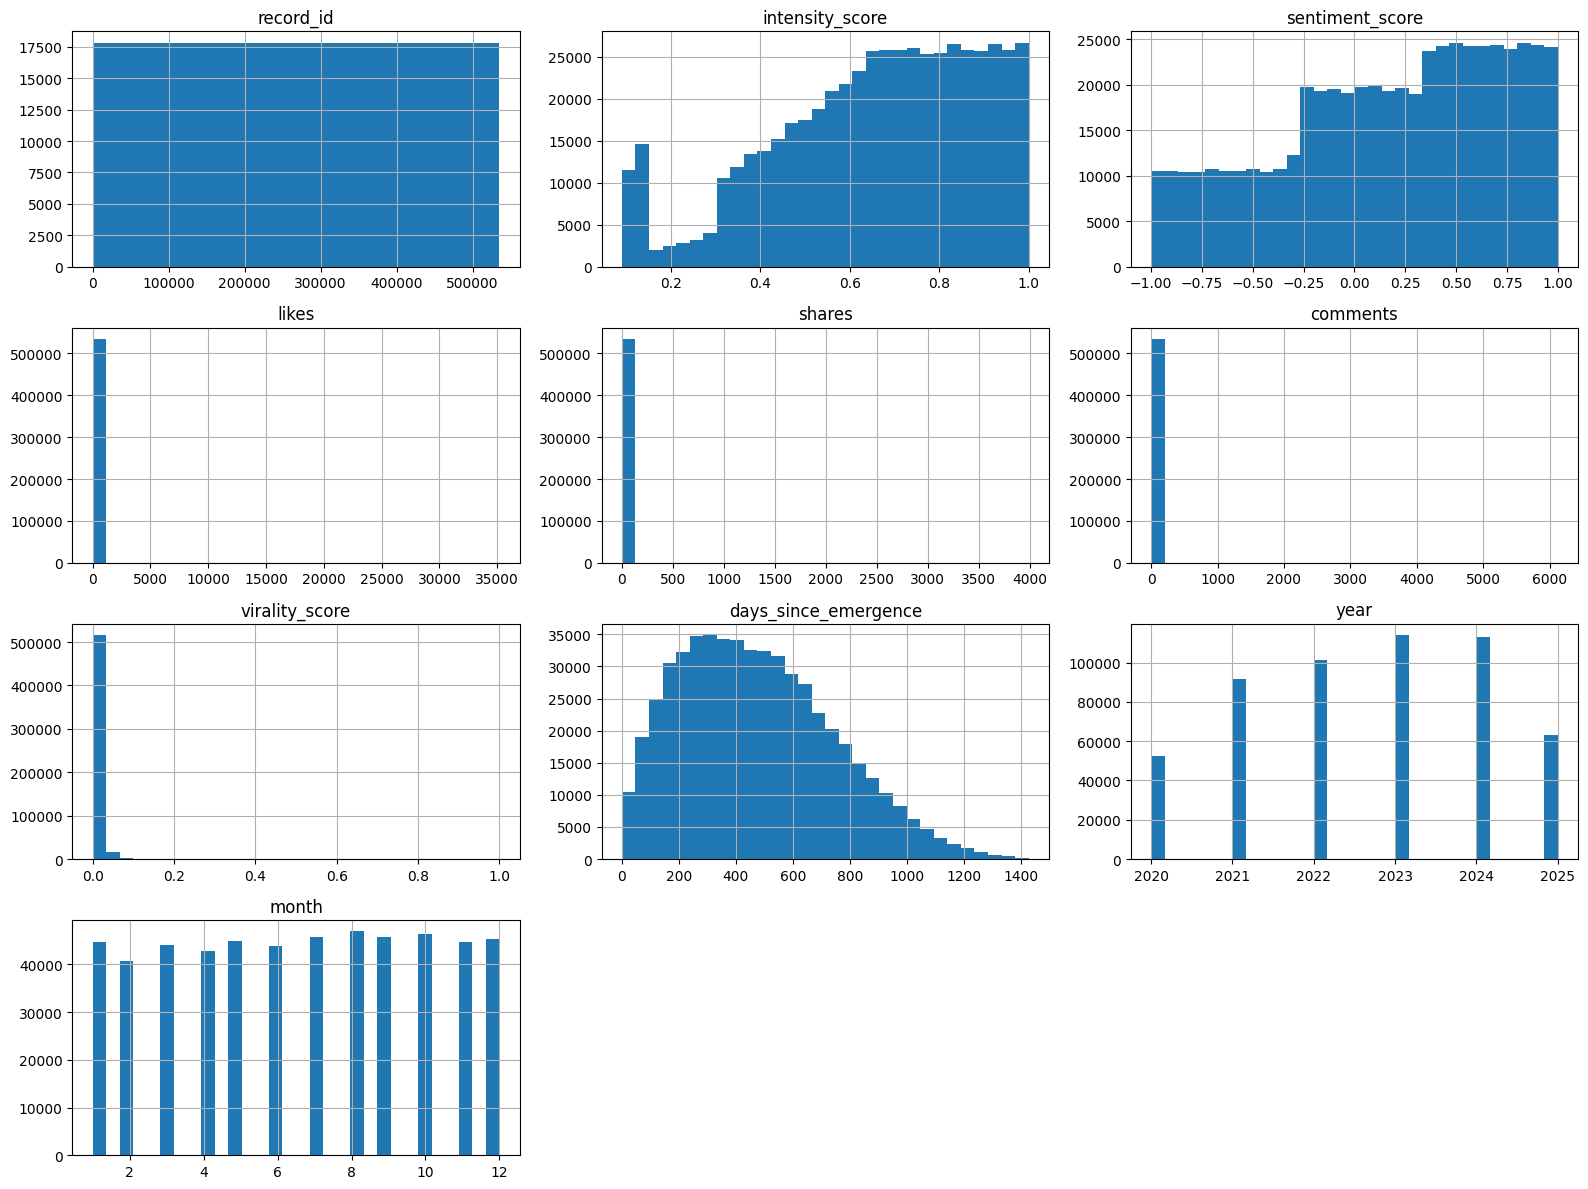

In [36]:
# Histograms for numeric variables
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

##  Time preprocessing and time distribution

Since the project's main axis is about **evolution over time and across platforms**, the timestamp is especially important.

We first make sure it is a proper datetime, then we look at how records are distributed over time.

Records per year:
year
2020     52592
2021     91597
2022    101347
2023    114006
2024    112845
2025     63009
Name: count, dtype: int64


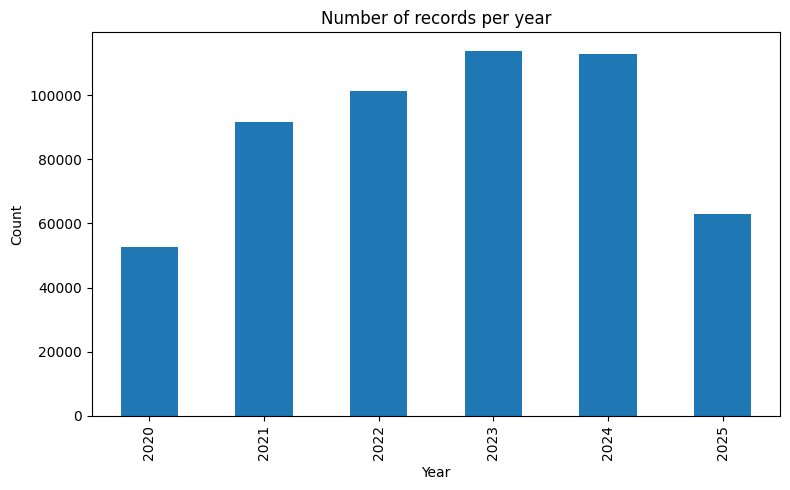

In [37]:
# Records per year
year_counts = df["year"].value_counts().sort_index()
print("Records per year:")
print(year_counts)

plt.figure(figsize=(8, 5))
year_counts.plot(kind="bar")
plt.title("Number of records per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

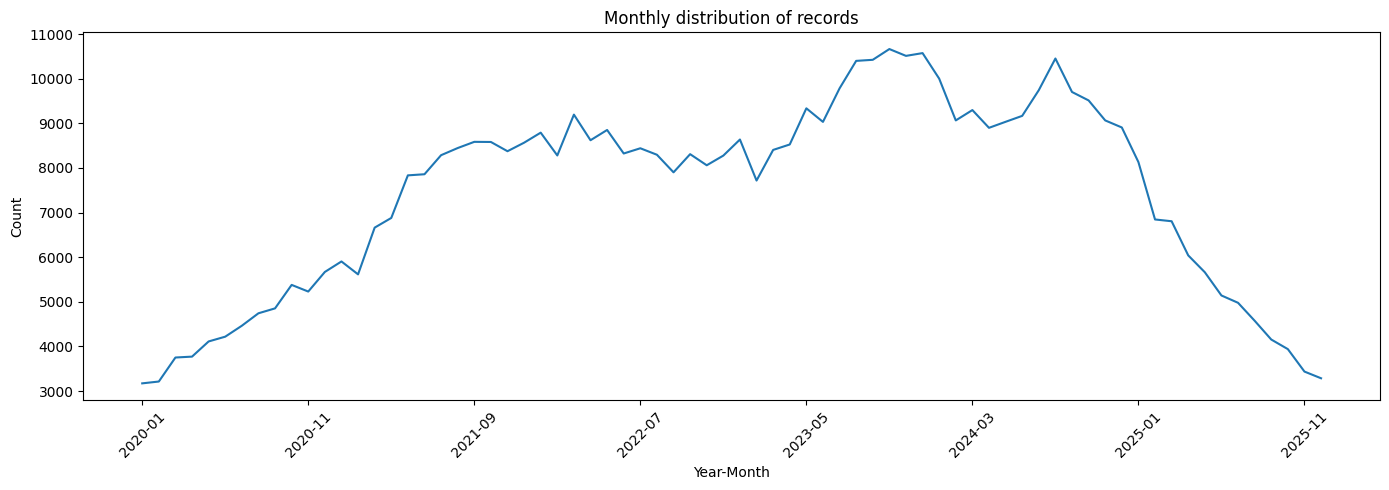

In [38]:
# Records per month (more detailed time view)
monthly_counts = df.groupby("year_month").size()

plt.figure(figsize=(14, 5))
monthly_counts.plot(kind="line")
plt.title("Monthly distribution of records")
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Recurrence of slang terms

Your teammate suggested a representation where **the most recurrent terms appear more strongly**.

For clarity in the report, a **bar chart** is usually better than a word cloud because it is easier to read and compare.
Still, I include an **optional word cloud** below.

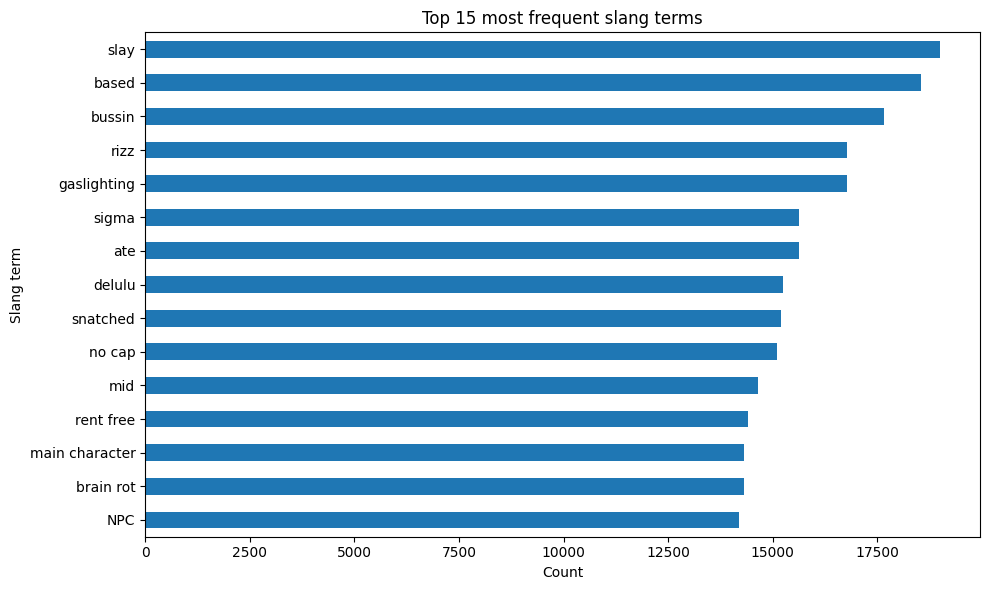

slang_term
slay              19004
based             18541
bussin            17651
rizz              16782
gaslighting       16766
sigma             15630
ate               15626
delulu            15244
snatched          15201
no cap            15107
mid               14642
rent free         14401
brain rot         14324
main character    14324
NPC               14194
Name: count, dtype: int64

In [39]:
top_slang = df["slang_term"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_slang.sort_values().plot(kind="barh")
plt.title("Top 15 most frequent slang terms")
plt.xlabel("Count")
plt.ylabel("Slang term")
plt.tight_layout()
plt.show()

top_slang

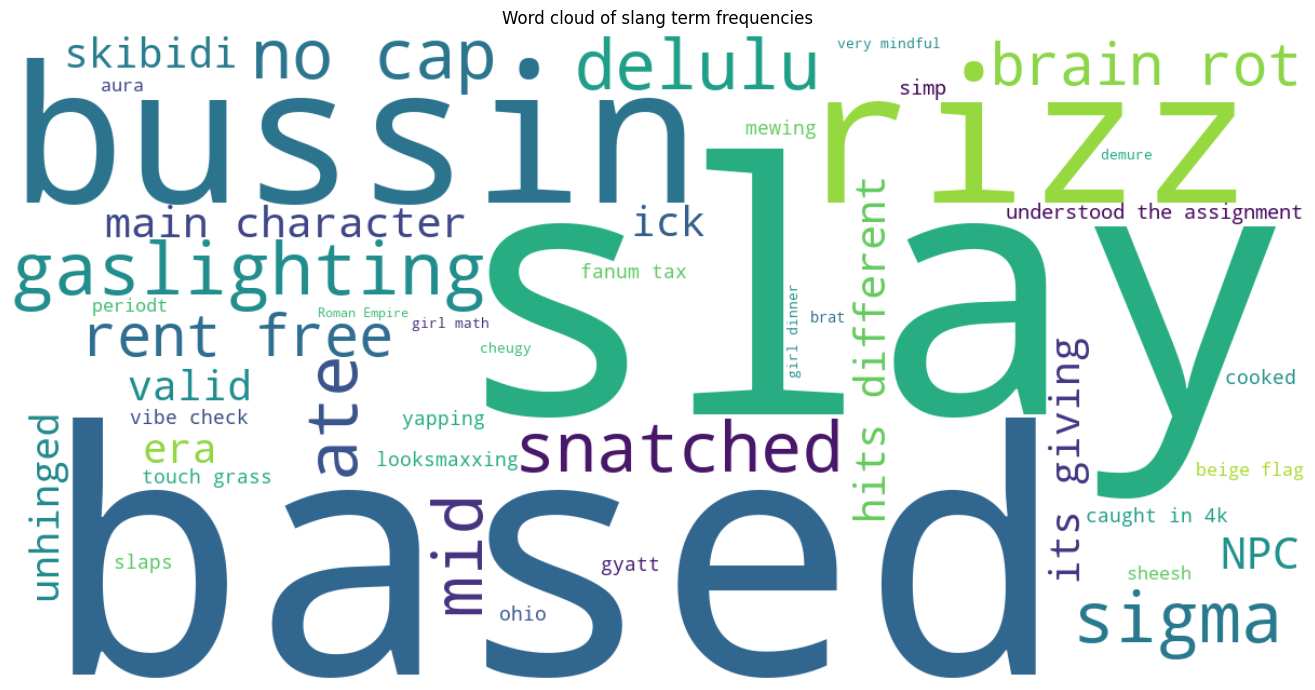

In [40]:
# Word cloud

try:
    from wordcloud import WordCloud

    frequencies = df["slang_term"].value_counts().to_dict()
    wordcloud = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(frequencies)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud of slang term frequencies")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Optional package 'wordcloud' is not installed.")
 

## Pie charts for important categorical variables

These charts answer simple questions like:
- Which platform appears most as `origin_platform`?
- Which platform appears most as `usage_platform`?
- Which age group is most represented?


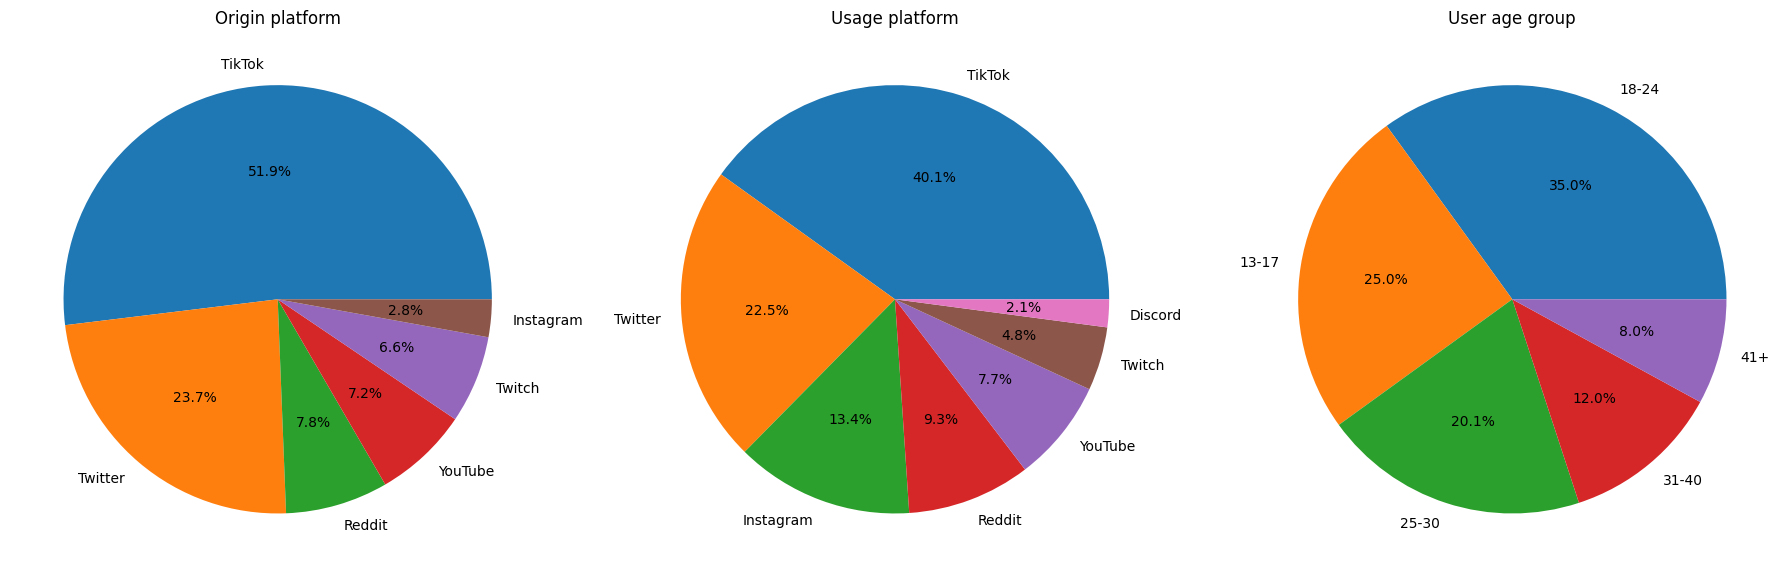

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df["origin_platform"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[0])
axes[0].set_title("Origin platform")
axes[0].set_ylabel("")

df["usage_platform"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Usage platform")
axes[1].set_ylabel("")

df["user_age_group"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[2])
axes[2].set_title("User age group")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

##  Bar plot of regions



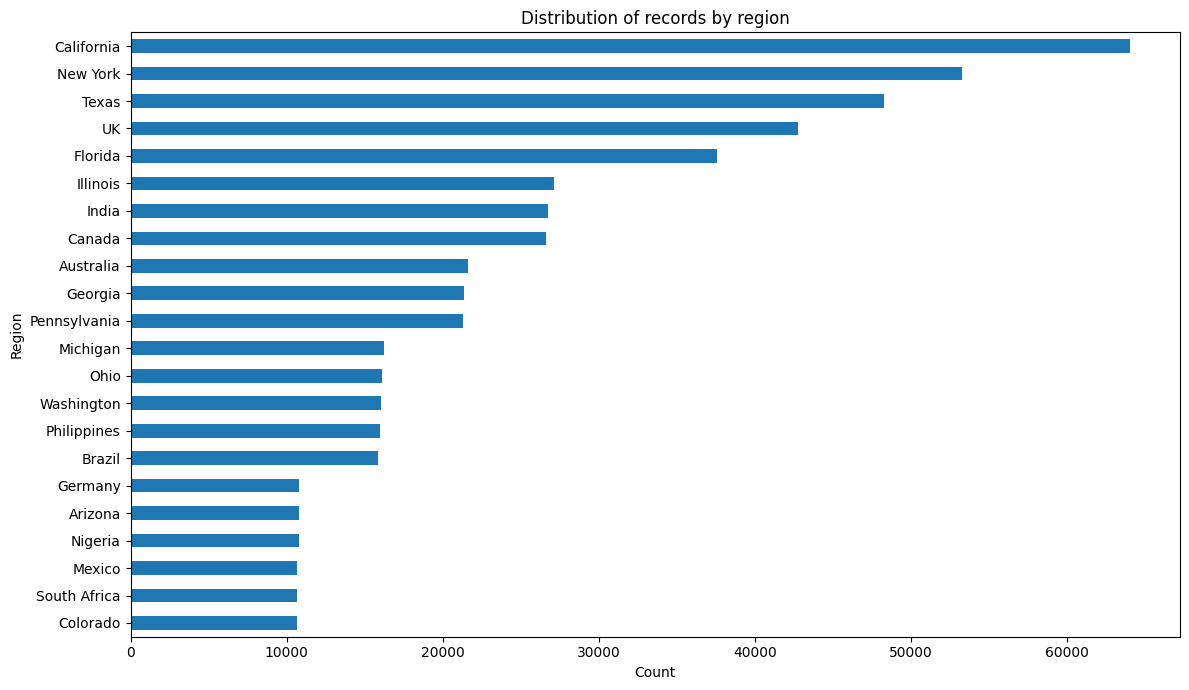

region
California      64047
New York        53272
Texas           48279
UK              42763
Florida         37550
Illinois        27159
India           26727
Canada          26624
Australia       21636
Georgia         21395
Pennsylvania    21292
Michigan        16231
Ohio            16110
Washington      16061
Philippines     15973
Brazil          15887
Germany         10806
Arizona         10792
Nigeria         10784
Mexico          10688
South Africa    10677
Colorado        10643
Name: count, dtype: int64

In [18]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(12, 7))
region_counts.sort_values().plot(kind="barh")
plt.title("Distribution of records by region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

region_counts

##  A platform view that matches the main axis of the project

Because the project is about **time + platforms**, we also compare activity by platform over time.

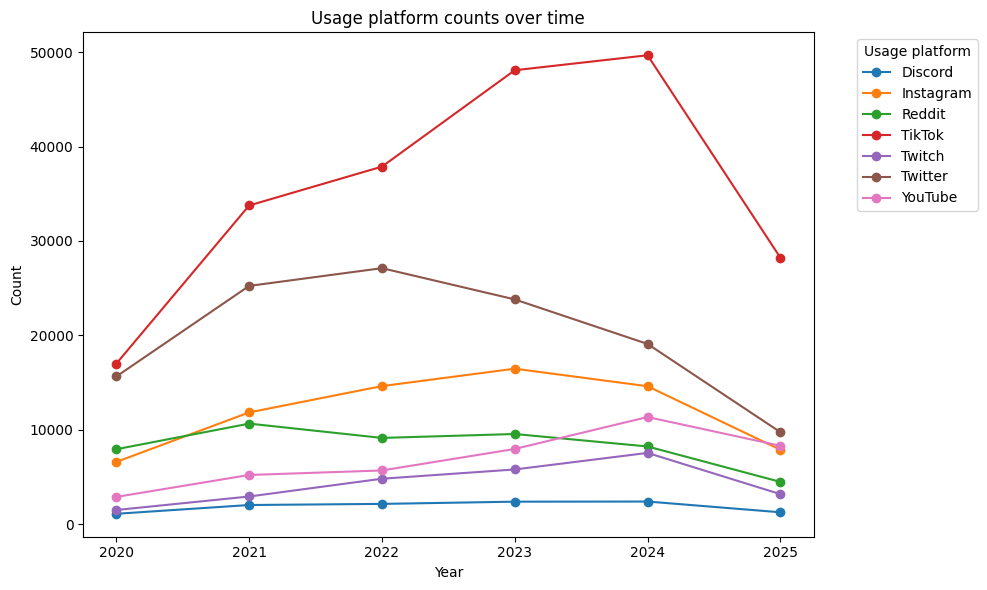

usage_platform,Discord,Instagram,Reddit,TikTok,Twitch,Twitter,YouTube
year,,,,,,,
2020,1084,6581,7927,17002,1487,15637,2874
2021,2015,11828,10641,33761,2917,25236,5199
2022,2133,14618,9125,37877,4801,27116,5677
2023,2369,16461,9540,48093,5783,23805,7955
2024,2383,14604,8219,49680,7537,19084,11338
2025,1245,7874,4466,28225,3167,9739,8293


In [19]:
platform_year = df.groupby(["year", "usage_platform"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
for col in platform_year.columns:
    plt.plot(platform_year.index, platform_year[col], marker="o", label=col)

plt.title("Usage platform counts over time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Usage platform", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

platform_year

In [20]:
origin_vs_usage = pd.crosstab(df["origin_platform"], df["usage_platform"])
origin_vs_usage

usage_platform,Discord,Instagram,Reddit,TikTok,Twitch,Twitter,YouTube
origin_platform,,,,,,,
Instagram,285,6496,1108,3734,402,2350,826
Reddit,912,5224,15288,10334,1139,6285,2321
TikTok,5761,35024,19385,151597,7795,42832,15634
Twitch,737,4467,2491,8680,11697,5461,1912
Twitter,2767,16004,8806,30857,3577,57760,7081
YouTube,767,4751,2840,9436,1082,5929,13562


##  Save the cleaned dataset

Saving the cleaned file is useful because:
- you do the pre-processing once
- you can reuse the cleaned data later for the final visualization

In [21]:
CLEAN_PATH = "genz_slang_usage_2020_2025_cleaned.csv"
df.to_csv(CLEAN_PATH, index=False)
print(f"Cleaned dataset saved as: {CLEAN_PATH}")

Cleaned dataset saved as: genz_slang_usage_2020_2025_cleaned.csv


## Main takeaways 

Based on this notebook, the main points we can already mention in the milestone are:

- the dataset is **large** and **well-structured**
- it has **no missing values** and **no duplicate rows**
- `timestamp` needed to be converted into datetime
- repeated text columns can be treated as **categorical**
- engagement variables (`likes`, `shares`, `comments`) are likely **skewed**, so outliers matter
- the dataset supports a project centered on **time, platforms, and slang diffusion**

This notebook gives you both the **pre-processing evidence** and a **basic EDA**.